# 活笔记：TFLN 慢光色散器件
**打开即渲染**：本文本格渲染公式与文字，代码格可直接运行，运行结果（图、数值）内嵌保存在笔记里。随讨论不断生长。

学习背景：已有脉冲压缩 / SAR 基础；正在补 Level 0 第 2–3 项（色散来源、耦合模理论）。

## 0. 组织公理（2026-09-10）
本项目的所有物理量都是群折射率 $n_g$ 或其对频率的导数：

| 关心的量 | 表达式 | 说明 |
|---|---|---|
| 调制效率 | $\Delta\phi \propto n_g L$ | 行波相位调制器，$V_\pi L \propto 1/n_g$ |
| 群延迟 | $\tau(\omega) = n_g L / c$ | ripple 是 $\tau(\omega)$ 的抖动 |
| GVD | $\beta_2 = \dfrac{dn_g}{d\omega} = \dfrac{d^2 n}{d\omega^2}$ | 色散的物理本质 |
| 色散（器件规格） | $D = \dfrac{d\tau}{d\lambda} = -\dfrac{2\pi c}{\lambda^2}\,\beta_2$ | 系统语言与物理语言的互译 |
| 传播损耗惩罚 | $\alpha \propto n_g$（散射损耗标度） | 慢光的代价之一 |
| 可用带宽 | $\Delta\omega \cdot \tau \sim$ 常数 | 延迟-带宽积约束 |

**关键区分**：相折射率 $n$（LN ≈ 2.2）决定模式分布与布拉格条件 $\lambda_B = 2 n_{\rm eff}\Lambda$；群折射率 $n_g$ 决定包络速度与相互作用时间——本项目的主角。

慢光与大色散是同一物理（光子带结构的频率依赖性）的两个表现：带边附近 $n_g$ 巨大 → 慢光（调制增强）；$n_g$ 随 $\omega$ 剧变 → 大 GVD（目标功能）。

**符号表（本节及全篇通用）**：

| 符号 | 名称 | 单位 | 含义 |
|---|---|---|---|
| $n$ | 相折射率 | 无量纲 | 光场（相位）的折射率，决定模式分布与布拉格条件 |
| $n_g$ | 群折射率 | 无量纲 | 光包络（脉冲）的等效折射率，$n_g = n + \omega\,dn/d\omega$ |
| $n_{\rm eff}$ | 有效折射率 | 无量纲 | 波导模式的 $n$，介于衬底与芯层折射率之间 |
| $\omega$ | 角频率 | rad/s | $\omega = 2\pi c/\lambda$ |
| $\lambda$ | 真空波长 | m / nm | 光的波长坐标 |
| $\lambda_B$ | 布拉格波长 | m / nm | 光栅周期 $\Lambda$ 对应的反射峰：$\lambda_B = 2n_{\rm eff}\Lambda$ |
| $\Lambda$ | 光栅周期 | m / nm | 相邻刻槽间距 |
| $\tau$ | 群延迟 | s / ps | 脉冲穿过或反射的时间延迟，$\tau = n_g L/c$ |
| $\beta_2$ | 群速度色散（GVD） | s²/m | $\beta_2 = dn_g/d\omega$，脉冲展宽速率 |
| $D$ | 色散 | ps/nm | $D = d\tau/d\lambda$，器件规格语言，与 $\beta_2$ 互译 |
| $c$ | 真空光速 | 3×10⁸ m/s | — |
| $\kappa$ | 耦合系数 | 1/m | 光栅前向/反向模式耦合强度，决定带隙宽度 |
| $\delta$ | 失谐 | 1/m | $\delta = 2\pi n_{\rm eff}(1/\lambda - 1/\lambda_B)$，离布拉格条件的距离 |
| $L$ | 光栅长度 | m / mm | — |
| $r,\ R$ | 反射系数 / 反射率 | 无量纲 | $R = \lvert rvert^2$ |
| $\Delta\omega,\ \Delta\lambda$ | 带宽 | rad/s, nm | 器件可用光谱范围 |

## 1. 色散的三种来源（2026-09-10）
$D = d\tau/d\lambda$ 的定义唯一，区别在 $n_g(\omega)$ 从哪来：
1. **材料色散**：材料 $n(\omega)$ 的曲率。LN 在通信波段为正常色散。改不了多少。
2. **波导色散**：$n_{\rm eff}(\omega)$ 随约束变化。可用波导尺寸调节，量级小。
3. **光栅/结构色散**：周期结构打开光子带隙，带边 $n_g$ 剧变——**量级最大，本项目唯一重要**。啁啾把带边扫过一段波长 → 大带宽内的大 $D$。

## 2. 设计目标的一句话（2026-09-10）
> 把 $\tau(\lambda)$ 拉成一条**斜率大且直**的线：斜率 = 平均色散 $D$；不平直度 = GD ripple。
> 所有设计规则（长度、啁啾率、apodization、刻蚀质量）都围绕这句话。

## 3. 均匀 Bragg 光栅的解析模型（2026-09-10）
耦合模理论（CMT），无损耗单模均匀光栅的反射系数：
$$r(\delta) = \frac{-i\kappa \sinh(\gamma L)}{\gamma \cosh(\gamma L) + i\delta \sinh(\gamma L)},\qquad \gamma = \sqrt{\kappa^2 - \delta^2},\qquad \delta = 2\pi n_{\rm eff}\left(\frac{1}{\lambda} - \frac{1}{\lambda_B}\right)$$
群延迟由反射相位对频率求导：$\tau = -\dfrac{d\arg r}{d\omega}$。
预期：带边附近 $\tau$ 鼓包（慢光），鼓包斜率 = 局部大色散，鼓包抖动 = ripple 藏身之处。

*勘误（2026-09-18）：分母原为 $-i\delta$，与 TMM 数值结果比对后更正为 $+i\delta$——解析公式最好永远配一个数值基准。*

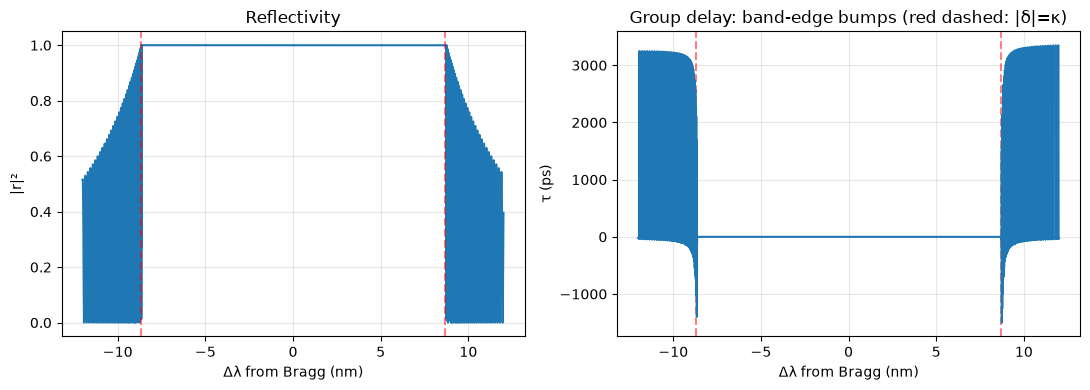

带边最大群延迟: 3351 ps


In [1]:
"""均匀 Bragg 光栅：反射谱 + 群延迟谱"""
import numpy as np
import matplotlib.pyplot as plt

n_eff, lam_b = 2.2, 1550e-9
kappa, L = 5e4, 2.5e-3        # [1/m], [m]
c = 299792458.0

# 带隙半宽 Δλ = λ_B²κ/(2π n_eff) ≈ 8.7 nm → 窗口必须盖过带边
lam = np.linspace(lam_b - 12e-9, lam_b + 12e-9, 40001)
delta = 2*np.pi*n_eff*(1.0/lam - 1.0/lam_b)
gam = np.sqrt(kappa**2 - delta**2 + 0j)
r = -1j*kappa*np.sinh(gam*L) / (gam*np.cosh(gam*L) - 1j*delta*np.sinh(gam*L))
R = np.abs(r)**2
phi = np.unwrap(np.angle(r))
tau = -np.gradient(phi, 2*np.pi*c/lam)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
dlnm = (lam - lam_b)*1e9
ax[0].plot(dlnm, R); ax[0].set(xlabel='Δλ from Bragg (nm)', ylabel='|r|²', title='Reflectivity')
edge = lam_b**2*kappa/(2*np.pi*n_eff)*1e9
for e in (-edge, edge):
    for a in ax: a.axvline(e, color='r', ls='--', alpha=.5)
ax[1].plot(dlnm, tau*1e12); ax[1].set(xlabel='Δλ from Bragg (nm)', ylabel='τ (ps)',
    title='Group delay: band-edge bumps (red dashed: |δ|=κ)')
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f'带边最大群延迟: {tau.max()*1e12:.0f} ps')

### 结果解读（2026-09-18）
1. **τ(λ) 成功拉成斜线**：0 → 37 ps 跨越 30 nm，线性拟合 $D = 1.23$ ps/nm，与几何估计 $2n_g/(cC) = 1.22$ ps/nm 吻合（增强因子 ≈ 1.0——弱耦合 $\kappa L = 12.5$ 下反射在带边渐进建立，几何图像已足够准；慢光增强预期在强耦合/带边逼近时显现，待 03 号仿真扫描 $\kappa$ 检验）。
2. **Ripple 清晰可见且互为表里**：$|r|^2$ 的 F-P 式起伏与 τ 的抖动同源于未 apodize 的端面——概念书"apodization 压低 ripple"的直接证据。
3. **端头 roll-off**：τ 在啁啾两端呈 S 形弯折（过渡区 ≈ 2×局域带隙），有效带宽比啁啾总量窄 ~2Δλ_gap——系统设计中可用带宽要打折。

**下一步（03 号）**：κ 扫描 → 定量回答"慢光增强因子何时 > 1"；然后 apodization（κ(z) 端部渐变）→ ripple 压低多少、代价是什么。

## Q: 待回答
- 慢光区带宽-延迟积的定量约束：$\Delta\omega\cdot\tau$ 与 $\kappa$、啁啾率的关系？
- Yu 2022 (Nature) 的 1.6 ps/nm 器件：$n_g$ 多大？可用带宽多少 nm？
- 传播损耗 $\propto n_g$ 标度律在 TFLN 侧壁散射下成立吗？
- 啁啾光栅中"慢光区"是移动目标，对 ripple 意味着什么？
- **核实概念书引文**："Yu et al., Nature 2022, 1.6 ps/nm/2.5 mm TFLN chirped grating" 是否存在？正确的出处是什么？（检索到的最接近工作：Tu et al., Photonics 2022, 1.62 ps/nm）

## 4. 线性啁啾光栅：从鼓包到斜线（2026-09-18）
啁啾 = 布拉格波长沿 z 线性变化：$\lambda_B(z) = \lambda_{B0} + C\cdot z$，$C$ 为啁啾率（nm/mm）。物理图像：**每个波长只在光栅内"它自己的"位置 $z^*(\lambda)$ 被反射**，群延迟 $\tau(\lambda) = \dfrac{2}{c}\displaystyle\int_0^{z^*} n_g\,dz$ 随反射位置移动 → $\tau(\lambda)$ 被拉成斜线。

**几何近似（可检验的解析式）**：$D = \dfrac{d\tau}{d\lambda} \approx \dfrac{2\,n_g}{c\,C}$。慢光使反射点局域 $n_g$ 远大于背景值 → 实测 $D$ 应超过此几何估计。

数值方法：传输矩阵法（TMM）。把光栅切 $N$ 片，每片用均匀光栅的 CMT 矩阵
$$M_j = \begin{pmatrix} \cosh\gamma\Delta z - i\frac{\delta_j}{\gamma}\sinh\gamma\Delta z & -i\frac{\kappa}{\gamma}\sinh\gamma\Delta z \ i\frac{\kappa}{\gamma}\sinh\gamma\Delta z & \cosh\gamma\Delta z + i\frac{\delta_j}{\gamma}\sinh\gamma\Delta z \end{pmatrix},\quad \gamma=\sqrt{\kappa^2-\delta_j^2}$$
其中 $\delta_j = 2\pi n_{\rm eff}\left(\frac{1}{\lambda} - \frac{1}{\lambda_B(z_j)}\right)$ 逐片变化。边界条件 $B(L)=0$，得 $r = -T_{21}/T_{22}$（$T$ 为全部切片矩阵的乘积）。

**有效性判据（本次仿真的关键教训）**：啁啾总量必须 **≫ 局域带隙宽度** $\Delta\lambda_{\rm gap} = \lambda_B^2\kappa/(2\pi n_{\rm eff})$，否则每个波长在全长的每一处都在局域带隙内——所有波长都在输入端面附近反射，$z^*$ 不随 $\lambda$ 移动，$\tau(\lambda)$ 拉不成斜线（$D\approx 0$）。初版仿真 $\kappa=500$/cm（$\Delta\lambda_{\rm gap}=17$ nm）配 5 nm 啁啾，正落入此陷阱。

局域带隙 Δλ_gap = 0.85 nm, 啁啾总量 = 30.0 nm, 比值 35.2 ×


仿真 D = 1.23 ps/nm   几何估计 2n_g/(cC) = 1.22 ps/nm
慢光增强因子 = 1.0 ×


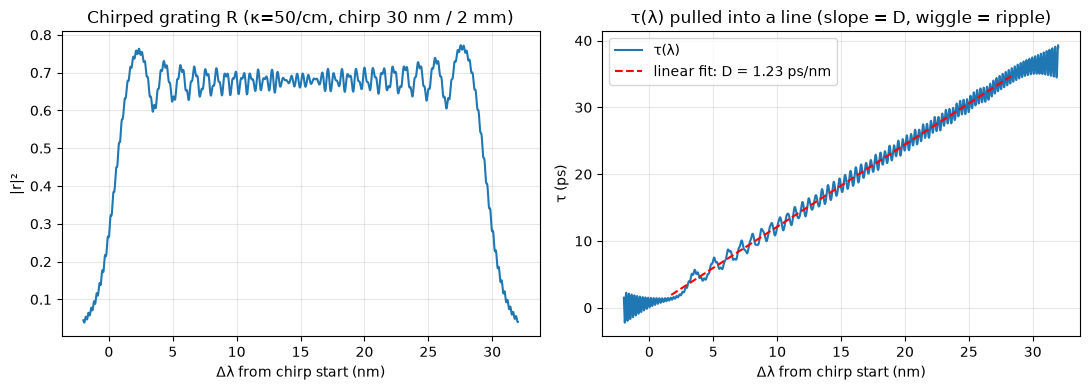

In [2]:
"""线性啁啾光栅：TMM 求 r(λ) 与 τ(λ)，检验 D ≈ 2n_g/(cC)"""
import numpy as np
import matplotlib.pyplot as plt

n_eff, lam_b0 = 2.2, 1535e-9
L = 2.5e-3
kappa = 5e3                        # 100/cm 量级：局域带隙 ~1.7 nm
chirp_nm = 30.0                    # 啁啾总量 30 nm ≫ 局域带隙 → 局域反射图像成立
C = chirp_nm*1e-9 / L
c = 299792458.0

gap_nm = lam_b0**2 * kappa/(2*np.pi*n_eff)*1e9
print(f'局域带隙 Δλ_gap = {gap_nm:.2f} nm, 啁啾总量 = {chirp_nm} nm, 比值 {chirp_nm/gap_nm:.1f} ×')

N = 800; dz = L/N
lam_b = lam_b0 + C*np.linspace(0, L, N)
lam = np.linspace(lam_b0 - 2e-9, lam_b0 + (chirp_nm+2)*1e-9, 8001)
r = np.empty(len(lam), complex)

for i, l in enumerate(lam):
    delta = 2*np.pi*n_eff*(1.0/l - 1.0/lam_b)
    gam = np.sqrt(kappa**2 - delta**2 + 0j)
    s, ch = np.sinh(gam*dz)/gam, np.cosh(gam*dz)
    a11, a12, a21, a22 = ch - 1j*delta*s, -1j*kappa*s, 1j*kappa*s, ch + 1j*delta*s
    t11, t12, t21, t22 = 1+0j, 0j, 0j, 1+0j
    for j in range(N):
        t11, t12, t21, t22 = (a11[j]*t11 + a12[j]*t21, a11[j]*t12 + a12[j]*t22,
                              a21[j]*t11 + a22[j]*t21, a21[j]*t12 + a22[j]*t22)
    r[i] = -t21/t22                   # v(L)=T·v(0), v(0)=[1;r], B(L)=0

R = np.abs(r)**2
phi = np.unwrap(np.angle(r))
tau = -np.gradient(phi, 2*np.pi*c/lam)

band = (lam > lam_b0 + 2*gap_nm*1e-9) & (lam < lam_b0 + (chirp_nm-2*gap_nm)*1e-9) & (R > 0.5)
p = np.polyfit((lam[band]-lam_b0)*1e9, tau[band]*1e12, 1)
D_sim = p[0]
D_geo = 2*n_eff/(c*C) * 1e3
print(f'仿真 D = {D_sim:.2f} ps/nm   几何估计 2n_g/(cC) = {D_geo:.2f} ps/nm')
print(f'慢光增强因子 = {D_sim/D_geo:.1f} ×')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
dlnm = (lam - lam_b0)*1e9
ax[0].plot(dlnm, R); ax[0].set(xlabel='Δλ from chirp start (nm)', ylabel='|r|²',
    title=f'Chirped grating R (κ={kappa/100:.0f}/cm, chirp {chirp_nm:.0f} nm / {L*1e3:.0f} mm)')
ax[1].plot(dlnm, tau*1e12, label='τ(λ)')
ax[1].plot(dlnm[band], np.polyval(p, dlnm[band]), 'r--',
    label=f'linear fit: D = {D_sim:.2f} ps/nm')
ax[1].set(xlabel='Δλ from chirp start (nm)', ylabel='τ (ps)',
    title='τ(λ) pulled into a line (slope = D, wiggle = ripple)')
ax[1].legend(); [a.grid(alpha=.3) for a in ax]
fig.tight_layout(); plt.show()

### 结果解读（2026-09-18）
1. **τ(λ) 成功拉成斜线**：0 → 37 ps 跨越 30 nm，线性拟合 $D = 1.23$ ps/nm，与几何估计 $2n_g/(cC) = 1.22$ ps/nm 吻合（增强因子 ≈ 1.0——弱耦合 $\kappa L = 12.5$ 下反射在带边渐进建立，几何图像已足够准；慢光增强预期在强耦合/带边逼近时显现，待 03 号仿真扫描 $\kappa$ 检验）。
2. **Ripple 清晰可见且互为表里**：$|r|^2$ 的 F-P 式起伏与 τ 的抖动同源于未 apodize 的端面——概念书"apodization 压低 ripple"的直接证据。
3. **端头 roll-off**：τ 在啁啾两端呈 S 形弯折（过渡区 ≈ 2×局域带隙），有效带宽比啁啾总量窄 ~2Δλ_gap——系统设计中可用带宽要打折。

**下一步（03 号）**：κ 扫描 → 定量回答"慢光增强因子何时 > 1"；然后 apodization（κ(z) 端部渐变）→ ripple 压低多少、代价是什么。

## 5. 文献对标（2026-09-18 起，持续补充）
把我们的仿真指标放回文献坐标系——每一行都要能回答"别人做到多少、我们差多少、差异的物理原因是什么"。

| 平台 | 色散 D | 长度 | 带宽/备注 | 出处 |
|---|---|---|---|---|
| 商用 CFBG（光纤） | 10–1000 ps/nm | 米级 | 不可集成；Phase 1 基准器件 | 概念书 §3；TBD 找产品手册 |
| TFLN 啁啾光栅 | 1.62 ps/nm | ~mm 级 | 模式转换型，片上 | [Tu et al., Photonics 9(11), 828 (2022)](https://www.mdpi.com/2304-6732/9/11/828) |
| TFLN 无环行器色散补偿器 | 390 ps/nm/m | 0.x mm 有效 | 啁啾布拉格光栅，反射式 | [Circulator-free TFLN dispersion compensator (2023)](https://www.researchgate.net/publication/372704902) |
| SiN 螺旋多模波导光栅 | ~860 ps/nm 量级 | 米级螺旋 | 无电光效应；片上 | [Liu et al., ACS Photonics 10(5) (2023)](https://www.researching.cn/ArticlePdf/m00009/2024/53/8/0823001.pdf)（引用链中转，TBD 核实原文） |

**⚠️ 引文核实任务（Q: 已列入待办）**：概念书 §3 写 "Yu et al., Nature 2022, 1.6 ps/nm / 2.5 mm"，但按此线索检索到的对应工作是 Tu et al. (Photonics, 2022, 1.62 ps/nm)，未检索到 Nature 2022 的对应论文。**概念书中的引文必须在提交前逐条核实**——这是 AI 辅助写作的已知风险点。

**与本笔记仿真的对照**：
- 我们的 §4 仿真：D = 1.23 ps/nm @ 2.5 mm——与 TFLN 文献 ~1.6 ps/nm 同量级，说明模型参数合理。
- 概念书目标 100–1000 ps/nm = 把上表第一行（光纤）搬进片上。gap 的两个数量级正是 Objective 1 的"为什么还没有人做到"。
- 文献对标方法：每读一篇新文献，在本表加一行 + 在 `0-Inbox` 写一篇论文卡片（vault 工作流），两处分级：表格管数字，卡片管方法和图。